In [2]:
%pip uninstall -y numpy onnxruntime insightface torch torchvision torchaudio albumentations
%pip install --no-cache-dir numpy==1.26.4
%pip install --no-cache-dir onnxruntime==1.19.2
%pip install --no-cache-dir insightface==0.7.3

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: onnxruntime 1.19.2
Uninstalling onnxruntime-1.19.2:
  Successfully uninstalled onnxruntime-1.19.2
Found existing installation: insightface 0.7.3
Uninstalling insightface-0.7.3:
  Successfully uninstalled insightface-0.7.3
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ----- ---------------------------------- 2.4/15.8 MB 14.9 MB/s eta 0:00:01
   ------------- -------------------------- 5.2/15.8 MB 13.8 MB/s eta 0:00:01
   --------------------- ------------------ 8.7/15.8 MB 14.5 MB/s eta 0:00:01
   ------------------------------ --------- 12.1/15.8 MB 15.1 MB/s eta 0:00:01
   ------------------------------------- -- 14.9/15.8 MB 14.9 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 14.6 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 1.13.0 requires torch>=2.0.0, which is not installed.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 2.4 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/11.1 MB 4.2 MB/s eta 0:00:03
   -------------- ------------------------- 3.9/11.1 MB 5.9 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.1 MB 7.1 MB/s eta 0:00:01
   ------------------------------------ --- 10.2/11.1 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 9.9 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started


In [1]:
import sys
import numpy as np

print("Python:", sys.executable)
print("NumPy:", np.__version__)

import onnxruntime
print("onnxruntime:", onnxruntime.__version__)

import insightface
print("insightface:", insightface.__version__)

from insightface.app import FaceAnalysis
print("FaceAnalysis import worked")

Python: c:\Users\maryc\AppData\Local\Programs\Python\Python311\python.exe
NumPy: 1.26.4
onnxruntime: 1.19.2


c:\Users\maryc\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


insightface: 0.7.3
FaceAnalysis import worked


In [2]:
from insightface.app import FaceAnalysis

app = FaceAnalysis(name="buffalo_l", providers=["CPUExecutionProvider"])
app.prepare(ctx_id=-1)
print("FaceAnalysis ready")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\maryc/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\maryc/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\maryc/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\maryc/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\maryc/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

In [3]:
from pathlib import Path

FOLDERS = {
    "failed_near_human": Path(r"C:\Users\maryc\Downloads\881project\uncannyrobot"),
    "stylized": Path(r"C:\Users\maryc\Downloads\881project\stylishedrobot"),
    "human_conventional": Path(r"C:\Users\maryc\Downloads\881project\conventionalfaces"),
    "human_unconventional": Path(r"C:\Users\maryc\Downloads\881project\unconventionalfaces"),
}

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

In [4]:
import cv2
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances
from scipy.stats import binomtest

def list_images(folder):
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS])

def get_largest_face(faces):
    if len(faces) == 0:
        return None
    faces = sorted(
        faces,
        key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]),
        reverse=True
    )
    return faces[0]

In [5]:
rows = []
embeddings = []

for group, folder in FOLDERS.items():
    files = list_images(folder)
    print(f"\nProcessing {group}: {len(files)} files")

    ok_count = 0
    fail_count = 0

    for path in files:
        img = cv2.imread(str(path))
        if img is None:
            fail_count += 1
            continue

        faces = app.get(img)
        face = get_largest_face(faces)

        if face is None:
            fail_count += 1
            continue

        emb = np.asarray(face.embedding, dtype=np.float32)

        rows.append({
            "group": group,
            "path": str(path),
            "filename": path.name
        })
        embeddings.append(emb)
        ok_count += 1

    print(f"Usable: {ok_count} | Failed: {fail_count}")

df_ok = pd.DataFrame(rows)
X = np.vstack(embeddings)

# store original embedding row index
df_ok = df_ok.reset_index().rename(columns={"index": "orig_idx"})

print("\nValid counts per group:")
print(df_ok["group"].value_counts())
print("\nEmbedding matrix shape:", X.shape)


Processing failed_near_human: 10 files


c:\Users\maryc\AppData\Local\Programs\Python\Python311\Lib\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
c:\Users\maryc\AppData\Local\Programs\Python\Python311\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Usable: 10 | Failed: 0

Processing stylized: 12 files
Usable: 7 | Failed: 5

Processing human_conventional: 249 files
Usable: 80 | Failed: 169

Processing human_unconventional: 31 files
Usable: 18 | Failed: 13

Valid counts per group:
group
human_conventional      80
human_unconventional    18
failed_near_human       10
stylized                 7
Name: count, dtype: int64

Embedding matrix shape: (115, 512)


In [6]:
GROUPS = [
    "failed_near_human",
    "stylized",
    "human_conventional",
    "human_unconventional",
]

group_counts = df_ok["group"].value_counts()
N = min(group_counts[g] for g in GROUPS)

print("Group counts:")
print(group_counts)
print(f"\nBalanced resampled size per group per iteration: {N}")

Group counts:
group
human_conventional      80
human_unconventional    18
failed_near_human       10
stylized                 7
Name: count, dtype: int64

Balanced resampled size per group per iteration: 7


In [7]:
def sample_group_with_replacement(df_group, n, rng):
    sampled_idx = rng.choice(df_group.index, size=n, replace=True)
    return df_group.loc[sampled_idx].copy().reset_index(drop=True)

In [8]:
rng = np.random.default_rng(42)

balanced_parts = []
for group in GROUPS:
    group_df = df_ok[df_ok["group"] == group]
    sampled = sample_group_with_replacement(group_df, N, rng)
    balanced_parts.append(sampled)

df_bal = pd.concat(balanced_parts, ignore_index=True).reset_index(drop=True)
X_bal = np.vstack([X[i] for i in df_bal["orig_idx"]])

print(df_bal["group"].value_counts())
print("Balanced embedding matrix shape:", X_bal.shape)

group
failed_near_human       7
stylized                7
human_conventional      7
human_unconventional    7
Name: count, dtype: int64
Balanced embedding matrix shape: (28, 512)


In [9]:
def rq1_single_iteration(df_ok, X, n_per_group, rng):
    balanced_parts = []

    for group in GROUPS:
        group_df = df_ok[df_ok["group"] == group]
        sampled = sample_group_with_replacement(group_df, n_per_group, rng)
        balanced_parts.append(sampled)

    df_bal_iter = pd.concat(balanced_parts, ignore_index=True).reset_index(drop=True)
    X_bal_iter = np.vstack([X[i] for i in df_bal_iter["orig_idx"]])

    mask_failed = (df_bal_iter["group"] == "failed_near_human").to_numpy()
    mask_hc = (df_bal_iter["group"] == "human_conventional").to_numpy()
    mask_hu = (df_bal_iter["group"] == "human_unconventional").to_numpy()

    failed_X = X_bal_iter[mask_failed]
    hc_X = X_bal_iter[mask_hc]
    hu_X = X_bal_iter[mask_hu]

    failed_paths = df_bal_iter.loc[mask_failed, "path"].tolist()

    # centroids
    hc_centroid = hc_X.mean(axis=0, keepdims=True)
    hu_centroid = hu_X.mean(axis=0, keepdims=True)

    dist_to_hc = euclidean_distances(failed_X, hc_centroid).reshape(-1)
    dist_to_hu = euclidean_distances(failed_X, hu_centroid).reshape(-1)

    # positive delta => closer to unconventional
    delta = dist_to_hc - dist_to_hu

    # nearest-neighbor
    D_to_hc = euclidean_distances(failed_X, hc_X)
    D_to_hu = euclidean_distances(failed_X, hu_X)

    nearest_hc_dist = D_to_hc.min(axis=1)
    nearest_hu_dist = D_to_hu.min(axis=1)

    nearest_group = np.where(
        nearest_hu_dist < nearest_hc_dist,
        "human_unconventional",
        "human_conventional"
    )

    out = pd.DataFrame({
        "failed_path": failed_paths,
        "dist_to_conventional_centroid": dist_to_hc,
        "dist_to_unconventional_centroid": dist_to_hu,
        "delta_conv_minus_unconv": delta,
        "centroid_closer_to": np.where(delta > 0, "human_unconventional", "human_conventional"),
        "nearest_group": nearest_group
    })

    return out

In [10]:
rng = np.random.default_rng(42)
rq1_once = rq1_single_iteration(df_ok, X, N, rng)

print(rq1_once.head())
print("\nCentroid closer counts:")
print(rq1_once["centroid_closer_to"].value_counts())

print("\nNearest-neighbor counts:")
print(rq1_once["nearest_group"].value_counts())

print("\nMean delta:")
print(rq1_once["delta_conv_minus_unconv"].mean())

                                         failed_path  \
0  C:\Users\maryc\Downloads\881project\uncannyrob...   
1  C:\Users\maryc\Downloads\881project\uncannyrob...   
2  C:\Users\maryc\Downloads\881project\uncannyrob...   
3  C:\Users\maryc\Downloads\881project\uncannyrob...   
4  C:\Users\maryc\Downloads\881project\uncannyrob...   

   dist_to_conventional_centroid  dist_to_unconventional_centroid  \
0                      24.864246                        24.646612   
1                      23.172720                        24.670681   
2                      24.660048                        26.430298   
3                      22.908638                        23.827776   
4                      22.908638                        23.827776   

   delta_conv_minus_unconv    centroid_closer_to       nearest_group  
0                 0.217634  human_unconventional  human_conventional  
1                -1.497961    human_conventional  human_conventional  
2                -1.770250    human

In [11]:
def run_rq1_bootstrap(df_ok, X, n_per_group, n_iterations=1000, seed=42):
    rng = np.random.default_rng(seed)

    summary_rows = []
    all_rows = []

    for it in range(n_iterations):
        iter_df = rq1_single_iteration(df_ok, X, n_per_group, rng)

        n_cent_unconv = (iter_df["centroid_closer_to"] == "human_unconventional").sum()
        n_cent_conv = (iter_df["centroid_closer_to"] == "human_conventional").sum()

        n_nn_unconv = (iter_df["nearest_group"] == "human_unconventional").sum()
        n_nn_conv = (iter_df["nearest_group"] == "human_conventional").sum()

        summary_rows.append({
            "iteration": it,
            "mean_dist_to_conventional": iter_df["dist_to_conventional_centroid"].mean(),
            "mean_dist_to_unconventional": iter_df["dist_to_unconventional_centroid"].mean(),
            "mean_delta": iter_df["delta_conv_minus_unconv"].mean(),
            "median_delta": iter_df["delta_conv_minus_unconv"].median(),
            "centroid_unconventional_count": n_cent_unconv,
            "centroid_conventional_count": n_cent_conv,
            "nn_unconventional_count": n_nn_unconv,
            "nn_conventional_count": n_nn_conv,
            "prop_centroid_unconventional": n_cent_unconv / len(iter_df),
            "prop_nn_unconventional": n_nn_unconv / len(iter_df)
        })

        temp = iter_df.copy()
        temp["iteration"] = it
        all_rows.append(temp)

    summary_df = pd.DataFrame(summary_rows)
    all_df = pd.concat(all_rows, ignore_index=True)

    return summary_df, all_df

In [12]:
rq1_boot_df, rq1_all_df = run_rq1_bootstrap(
    df_ok=df_ok,
    X=X,
    n_per_group=N,
    n_iterations=1000,
    seed=42
)

In [13]:
print("=========== RQ1 BOOTSTRAP SUMMARY ===========")
print(f"Balanced resampled size per group: {N}")
print(f"Iterations: {len(rq1_boot_df)}")

print("\nAverage centroid distances:")
print("to conventional humans:", rq1_boot_df["mean_dist_to_conventional"].mean())
print("to unconventional humans:", rq1_boot_df["mean_dist_to_unconventional"].mean())

print("\nAverage mean delta (conv - unconv):")
print(rq1_boot_df["mean_delta"].mean())

print("\n95% CI for mean delta:")
print(rq1_boot_df["mean_delta"].quantile([0.025, 0.975]))

print("\nAverage proportion centroid-closer to unconventional:")
print(rq1_boot_df["prop_centroid_unconventional"].mean())

print("\n95% CI for centroid proportion:")
print(rq1_boot_df["prop_centroid_unconventional"].quantile([0.025, 0.975]))

print("\nAverage proportion nearest-neighbor closer to unconventional:")
print(rq1_boot_df["prop_nn_unconventional"].mean())

print("\n95% CI for nearest-neighbor proportion:")
print(rq1_boot_df["prop_nn_unconventional"].quantile([0.025, 0.975]))

=========== RQ1 BOOTSTRAP SUMMARY ===========
Balanced resampled size per group: 7
Iterations: 1000

Average centroid distances:
to conventional humans: 24.89776
to unconventional humans: 25.534939

Average mean delta (conv - unconv):
-0.63718045

95% CI for mean delta:
0.025   -2.221802
0.975    0.652987
Name: mean_delta, dtype: float64

Average proportion centroid-closer to unconventional:
0.2541428571428571

95% CI for centroid proportion:
0.025    0.000000
0.975    0.857143
Name: prop_centroid_unconventional, dtype: float64

Average proportion nearest-neighbor closer to unconventional:
0.44499999999999995

95% CI for nearest-neighbor proportion:
0.025    0.0
0.975    1.0
Name: prop_nn_unconventional, dtype: float64


In [44]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd
from scipy.stats import binomtest

In [45]:
def rq1_knn_single_iteration(df_ok, X, n_per_group, rng, k=3):
    """
    One balanced bootstrap iteration for RQ1 using k-NN.

    Train k-NN on:
        - human_conventional
        - human_unconventional

    Predict labels for:
        - failed_near_human
    """
    balanced_parts = []

    for group in GROUPS:
        group_df = df_ok[df_ok["group"] == group]
        sampled = sample_group_with_replacement(group_df, n_per_group, rng)
        balanced_parts.append(sampled)

    df_bal_iter = pd.concat(balanced_parts, ignore_index=True).reset_index(drop=True)
    X_bal_iter = np.vstack([X[i] for i in df_bal_iter["orig_idx"]])

    # masks
    mask_failed = (df_bal_iter["group"] == "failed_near_human").to_numpy()
    mask_hc = (df_bal_iter["group"] == "human_conventional").to_numpy()
    mask_hu = (df_bal_iter["group"] == "human_unconventional").to_numpy()

    # training set = only the two human groups
    X_train = np.vstack([X_bal_iter[mask_hc], X_bal_iter[mask_hu]])
    y_train = np.array(
        ["human_conventional"] * mask_hc.sum() +
        ["human_unconventional"] * mask_hu.sum()
    )

    # test set = failed near-human
    X_test = X_bal_iter[mask_failed]
    failed_paths = df_bal_iter.loc[mask_failed, "path"].tolist()

    # safeguard: k cannot exceed training size
    k_eff = min(k, len(X_train))
    if k_eff % 2 == 0:
        k_eff = max(1, k_eff - 1)

    knn = KNeighborsClassifier(n_neighbors=k_eff, metric="euclidean")
    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)
    prob = knn.predict_proba(X_test)

    # probability column order follows knn.classes_
    class_order = list(knn.classes_)

    out = pd.DataFrame({
        "failed_path": failed_paths,
        "predicted_group": pred
    })

    for i, cls in enumerate(class_order):
        out[f"prob_{cls}"] = prob[:, i]

    return out

In [46]:
def run_rq1_knn_bootstrap(df_ok, X, n_per_group, n_iterations=1000, seed=42, k=3):
    rng = np.random.default_rng(seed)

    summary_rows = []
    all_rows = []

    for it in range(n_iterations):
        iter_df = rq1_knn_single_iteration(
            df_ok=df_ok,
            X=X,
            n_per_group=n_per_group,
            rng=rng,
            k=k
        )

        n_unconv = (iter_df["predicted_group"] == "human_unconventional").sum()
        n_conv = (iter_df["predicted_group"] == "human_conventional").sum()

        summary_rows.append({
            "iteration": it,
            "k": k,
            "pred_unconventional_count": n_unconv,
            "pred_conventional_count": n_conv,
            "prop_pred_unconventional": n_unconv / len(iter_df)
        })

        temp = iter_df.copy()
        temp["iteration"] = it
        temp["k"] = k
        all_rows.append(temp)

    summary_df = pd.DataFrame(summary_rows)
    all_df = pd.concat(all_rows, ignore_index=True)

    return summary_df, all_df

In [48]:
rq1_knn_boot_df, rq1_knn_all_df = run_rq1_knn_bootstrap(
    df_ok=df_ok,
    X=X,
    n_per_group=N,
    n_iterations=1000,
    seed=42,
    k=3
)

In [49]:
print("=========== RQ1 k-NN BOOTSTRAP SUMMARY ===========")
print(f"Balanced resampled size per group: {N}")
print(f"Iterations: {len(rq1_knn_boot_df)}")
print(f"k: {rq1_knn_boot_df['k'].iloc[0]}")

print("\nAverage proportion predicted as unconventional:")
print(rq1_knn_boot_df["prop_pred_unconventional"].mean())

print("\n95% CI for proportion predicted as unconventional:")
print(rq1_knn_boot_df["prop_pred_unconventional"].quantile([0.025, 0.975]))

=========== RQ1 k-NN BOOTSTRAP SUMMARY ===========
Balanced resampled size per group: 7
Iterations: 1000
k: 3

Average proportion predicted as unconventional:
0.43828571428571433

95% CI for proportion predicted as unconventional:
0.025    0.0
0.975    1.0
Name: prop_pred_unconventional, dtype: float64


In [50]:
total_unconv = rq1_knn_boot_df["pred_unconventional_count"].sum()
total_conv = rq1_knn_boot_df["pred_conventional_count"].sum()
total = total_unconv + total_conv

binom_res = binomtest(total_unconv, total, p=0.5, alternative="greater")

print("k-NN binomial test")
print("Predicted unconventional:", total_unconv)
print("Predicted conventional:", total_conv)
print("Trials:", total)
print("P-value:", binom_res.pvalue)

k-NN binomial test
Predicted unconventional: 3068
Predicted conventional: 3932
Trials: 7000
P-value: 1.0


In [14]:
total_nn_unconv = rq1_boot_df["nn_unconventional_count"].sum()
total_nn_conv = rq1_boot_df["nn_conventional_count"].sum()
total_nn = total_nn_unconv + total_nn_conv

binom_res = binomtest(total_nn_unconv, total_nn, p=0.5, alternative="greater")

print("Nearest-neighbor binomial test")
print("Successes:", total_nn_unconv)
print("Trials:", total_nn)
print("P-value:", binom_res.pvalue)

Nearest-neighbor binomial test
Successes: 3115
Trials: 7000
P-value: 1.0


=========== RQ1 RBF-SVM BOOTSTRAP SUMMARY ===========
Balanced resampled size per group: 7
Iterations: 1000
C: 1.0
gamma: scale

Average proportion predicted as unconventional:
0.1561428571428571

95% CI for proportion predicted as unconventional:
0.025    0.0
0.975    1.0
Name: prop_pred_unconventional, dtype: float64

RBF-SVM binomial test
Predicted unconventional: 1093
Predicted conventional: 5907
Trials: 7000
P-value: 1.0


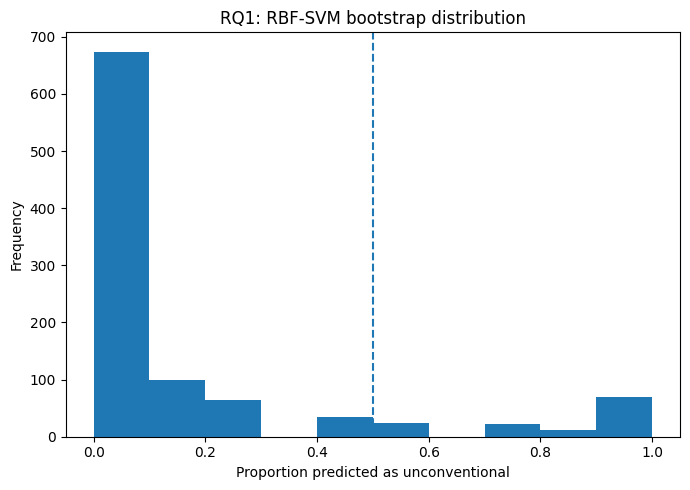

In [58]:
from sklearn.svm import SVC
from scipy.stats import binomtest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# RQ1 RBF-SVM BOOTSTRAP ON FULL EMBEDDINGS
# Uses the original facial embeddings directly
# =========================================================

def rq1_rbf_svm_single_iteration(df_ok, X, n_per_group, rng, C=1.0, gamma="scale"):
    balanced_parts = []

    for group in GROUPS:
        group_df = df_ok[df_ok["group"] == group]
        sampled = sample_group_with_replacement(group_df, n_per_group, rng)
        balanced_parts.append(sampled)

    df_bal_iter = pd.concat(balanced_parts, ignore_index=True).reset_index(drop=True)
    X_bal_iter = np.vstack([X[i] for i in df_bal_iter["orig_idx"]])

    # training groups
    mask_failed = (df_bal_iter["group"] == "failed_near_human").to_numpy()
    mask_hc = (df_bal_iter["group"] == "human_conventional").to_numpy()
    mask_hu = (df_bal_iter["group"] == "human_unconventional").to_numpy()

    X_train = np.vstack([X_bal_iter[mask_hc], X_bal_iter[mask_hu]])
    y_train = np.array(
        ["human_conventional"] * mask_hc.sum() +
        ["human_unconventional"] * mask_hu.sum()
    )

    X_test = X_bal_iter[mask_failed]
    failed_paths = df_bal_iter.loc[mask_failed, "path"].tolist()

    clf = SVC(kernel="rbf", C=C, gamma=gamma, probability=True, random_state=42)
    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)
    prob = clf.predict_proba(X_test)
    class_order = list(clf.classes_)

    out = pd.DataFrame({
        "failed_path": failed_paths,
        "predicted_group": pred
    })

    for i, cls in enumerate(class_order):
        out[f"prob_{cls}"] = prob[:, i]

    return out


def run_rq1_rbf_svm_bootstrap(df_ok, X, n_per_group, n_iterations=1000, seed=42, C=1.0, gamma="scale"):
    rng = np.random.default_rng(seed)

    summary_rows = []
    all_rows = []

    for it in range(n_iterations):
        iter_df = rq1_rbf_svm_single_iteration(
            df_ok=df_ok,
            X=X,
            n_per_group=n_per_group,
            rng=rng,
            C=C,
            gamma=gamma
        )

        n_unconv = (iter_df["predicted_group"] == "human_unconventional").sum()
        n_conv = (iter_df["predicted_group"] == "human_conventional").sum()

        summary_rows.append({
            "iteration": it,
            "C": C,
            "gamma": gamma,
            "pred_unconventional_count": n_unconv,
            "pred_conventional_count": n_conv,
            "prop_pred_unconventional": n_unconv / len(iter_df)
        })

        temp = iter_df.copy()
        temp["iteration"] = it
        temp["C"] = C
        temp["gamma"] = gamma
        all_rows.append(temp)

    summary_df = pd.DataFrame(summary_rows)
    all_df = pd.concat(all_rows, ignore_index=True)

    return summary_df, all_df


# -----------------------------
# RUN RBF-SVM BOOTSTRAP
# -----------------------------
rq1_rbf_svm_boot_df, rq1_rbf_svm_all_df = run_rq1_rbf_svm_bootstrap(
    df_ok=df_ok,
    X=X,
    n_per_group=N,
    n_iterations=1000,
    seed=42,
    C=1.0,
    gamma="scale"
)

print("=========== RQ1 RBF-SVM BOOTSTRAP SUMMARY ===========")
print(f"Balanced resampled size per group: {N}")
print(f"Iterations: {len(rq1_rbf_svm_boot_df)}")
print(f"C: {rq1_rbf_svm_boot_df['C'].iloc[0]}")
print(f"gamma: {rq1_rbf_svm_boot_df['gamma'].iloc[0]}")

print("\nAverage proportion predicted as unconventional:")
print(rq1_rbf_svm_boot_df["prop_pred_unconventional"].mean())

print("\n95% CI for proportion predicted as unconventional:")
print(rq1_rbf_svm_boot_df["prop_pred_unconventional"].quantile([0.025, 0.975]))

total_unconv = rq1_rbf_svm_boot_df["pred_unconventional_count"].sum()
total_conv = rq1_rbf_svm_boot_df["pred_conventional_count"].sum()
total = total_unconv + total_conv

binom_res = binomtest(total_unconv, total, p=0.5, alternative="greater")

print("\nRBF-SVM binomial test")
print("Predicted unconventional:", total_unconv)
print("Predicted conventional:", total_conv)
print("Trials:", total)
print("P-value:", binom_res.pvalue)

plt.figure(figsize=(7,5))
plt.hist(rq1_rbf_svm_boot_df["prop_pred_unconventional"], bins=10)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Proportion predicted as unconventional")
plt.ylabel("Frequency")
plt.title("RQ1: RBF-SVM bootstrap distribution")
plt.tight_layout()
plt.savefig("rq1_rbf_svm_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

rq1_rbf_svm_boot_df.to_csv("rq1_rbf_svm_bootstrap_summary.csv", index=False)
rq1_rbf_svm_all_df.to_csv("rq1_rbf_svm_bootstrap_all_predictions.csv", index=False)

In [15]:
df_ok.to_csv("rq1_valid_images_metadata.csv", index=False)
np.save("rq1_all_embeddings.npy", X)
rq1_boot_df.to_csv("rq1_bootstrap_summary.csv", index=False)
rq1_all_df.to_csv("rq1_bootstrap_all_image_results.csv", index=False)

print("Saved:")
print("- rq1_valid_images_metadata.csv")
print("- rq1_all_embeddings.npy")
print("- rq1_bootstrap_summary.csv")
print("- rq1_bootstrap_all_image_results.csv")

Saved:
- rq1_valid_images_metadata.csv
- rq1_all_embeddings.npy
- rq1_bootstrap_summary.csv
- rq1_bootstrap_all_image_results.csv


rrq2

In [16]:
import cv2
import numpy as np
import pandas as pd
from scipy.stats import zscore

In [19]:
def crop_with_margin(img, bbox, margin_ratio=0.20):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = map(int, bbox)

    bw = x2 - x1
    bh = y2 - y1

    mx = int(bw * margin_ratio)
    my = int(bh * margin_ratio)

    x1 = max(0, x1 - mx)
    y1 = max(0, y1 - my)
    x2 = min(w, x2 + mx)
    y2 = min(h, y2 + my)

    return img[y1:y2, x1:x2]

In [20]:
def compute_face_coherence_features(face_crop):
    """
    Returns handcrafted coherence-related image features for one face crop.
    """
    gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)

    # Resize to keep feature extraction more stable
    gray = cv2.resize(gray, (160, 160))

    h, w = gray.shape
    mid = w // 2

    left = gray[:, :mid]
    right = gray[:, w - mid:]
    right_flipped = np.fliplr(right)

    # 1. symmetry difference (lower = more symmetric / more coherent)
    symmetry_diff = np.mean(np.abs(left.astype(np.float32) - right_flipped.astype(np.float32)))

    # 2. texture variance
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    texture_variance = float(np.var(lap))

    # 3. edge density
    edges = cv2.Canny(gray, 100, 200)
    edge_density = float(edges.mean() / 255.0)

    # 4. intensity variance
    intensity_variance = float(np.var(gray.astype(np.float32)))

    # 5. center-border difference
    center = gray[h//4:3*h//4, w//4:3*w//4]
    border_mask = np.ones_like(gray, dtype=bool)
    border_mask[h//4:3*h//4, w//4:3*w//4] = False
    border_pixels = gray[border_mask]

    center_border_diff = float(abs(center.mean() - border_pixels.mean()))

    return {
        "symmetry_diff": symmetry_diff,
        "texture_variance": texture_variance,
        "edge_density": edge_density,
        "intensity_variance": intensity_variance,
        "center_border_diff": center_border_diff
    }

In [21]:
coherence_rows = []

for i, row in df_ok.iterrows():
    img = cv2.imread(row["path"])
    if img is None:
        continue

    faces = app.get(img)
    face = get_largest_face(faces)
    if face is None:
        continue

    crop = crop_with_margin(img, face.bbox, margin_ratio=0.20)

    if crop is None or crop.size == 0:
        continue

    feats = compute_face_coherence_features(crop)

    coherence_rows.append({
        "orig_idx": row["orig_idx"],
        "group": row["group"],
        "path": row["path"],
        **feats
    })

coh_df = pd.DataFrame(coherence_rows)
print(coh_df.head())
print("\nCounts in coherence dataframe:")
print(coh_df["group"].value_counts())

c:\Users\maryc\AppData\Local\Programs\Python\Python311\Lib\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
c:\Users\maryc\AppData\Local\Programs\Python\Python311\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


   orig_idx              group  \
0         0  failed_near_human   
1         1  failed_near_human   
2         2  failed_near_human   
3         3  failed_near_human   
4         4  failed_near_human   

                                                path  symmetry_diff  \
0  C:\Users\maryc\Downloads\881project\uncannyrob...      40.975624   
1  C:\Users\maryc\Downloads\881project\uncannyrob...      26.349140   
2  C:\Users\maryc\Downloads\881project\uncannyrob...      64.448441   
3  C:\Users\maryc\Downloads\881project\uncannyrob...      39.004375   
4  C:\Users\maryc\Downloads\881project\uncannyrob...      47.112656   

   texture_variance  edge_density  intensity_variance  center_border_diff  
0       2599.131836      0.183945         5597.345215            9.794271  
1        244.453537      0.050937         3554.057617           88.532344  
2        760.119324      0.067695         3466.998047           37.235625  
3       1306.448486      0.069219         4228.834473           

In [22]:
feature_cols = [
    "symmetry_diff",
    "texture_variance",
    "edge_density",
    "intensity_variance",
    "center_border_diff"
]

# z-score each feature
for col in feature_cols:
    coh_df[col + "_z"] = zscore(coh_df[col].astype(float), nan_policy="omit")

# coherence score:
# higher score = more coherent
# since larger values of these mismatch features usually mean less coherence,
# we negate them before averaging
z_cols = [col + "_z" for col in feature_cols]

coh_df["coherence_score"] = -coh_df[z_cols].mean(axis=1)

print(coh_df[["group", "coherence_score"]].head())

               group  coherence_score
0  failed_near_human        -1.774397
1  failed_near_human        -0.089143
2  failed_near_human        -0.451415
3  failed_near_human        -0.536769
4  failed_near_human        -0.789278


In [23]:
rq2_counts = coh_df["group"].value_counts()
N_rq2 = min(rq2_counts[g] for g in GROUPS)

print("RQ2 group counts:")
print(rq2_counts)
print(f"\nBalanced resampled size per group per iteration for RQ2: {N_rq2}")

RQ2 group counts:
group
human_conventional      80
human_unconventional    18
failed_near_human       10
stylized                 7
Name: count, dtype: int64

Balanced resampled size per group per iteration for RQ2: 7


In [24]:
def rq2_single_iteration(coh_df, n_per_group, rng):
    balanced_parts = []

    for group in GROUPS:
        group_df = coh_df[coh_df["group"] == group]
        sampled = sample_group_with_replacement(group_df, n_per_group, rng)
        balanced_parts.append(sampled)

    df_bal_iter = pd.concat(balanced_parts, ignore_index=True).reset_index(drop=True)

    group_means = (
        df_bal_iter.groupby("group")["coherence_score"]
        .mean()
        .to_dict()
    )

    return df_bal_iter, group_means

In [25]:
rng = np.random.default_rng(42)
rq2_once_df, rq2_once_means = rq2_single_iteration(coh_df, N_rq2, rng)

print("One-iteration group means:")
print(rq2_once_means)

One-iteration group means:
{'failed_near_human': -0.9403680901952517, 'human_conventional': 0.1821583796349739, 'human_unconventional': 0.21310168092236864, 'stylized': 0.05179439452671936}


In [26]:
def run_rq2_bootstrap(coh_df, n_per_group, n_iterations=1000, seed=42):
    rng = np.random.default_rng(seed)

    summary_rows = []
    all_rows = []

    for it in range(n_iterations):
        iter_df, group_means = rq2_single_iteration(coh_df, n_per_group, rng)

        summary_rows.append({
            "iteration": it,
            "mean_failed_near_human": group_means.get("failed_near_human", np.nan),
            "mean_stylized": group_means.get("stylized", np.nan),
            "mean_human_conventional": group_means.get("human_conventional", np.nan),
            "mean_human_unconventional": group_means.get("human_unconventional", np.nan),
        })

        temp = iter_df.copy()
        temp["iteration"] = it
        all_rows.append(temp)

    summary_df = pd.DataFrame(summary_rows)
    all_df = pd.concat(all_rows, ignore_index=True)

    return summary_df, all_df

In [27]:
rq2_boot_df, rq2_all_df = run_rq2_bootstrap(
    coh_df=coh_df,
    n_per_group=N_rq2,
    n_iterations=1000,
    seed=42
)

In [28]:
print("=========== RQ2 BOOTSTRAP SUMMARY ===========")
print(f"Balanced resampled size per group: {N_rq2}")
print(f"Iterations: {len(rq2_boot_df)}")

for col in [
    "mean_failed_near_human",
    "mean_stylized",
    "mean_human_conventional",
    "mean_human_unconventional"
]:
    print(f"\n{col}:")
    print("mean =", rq2_boot_df[col].mean())
    print("95% CI =")
    print(rq2_boot_df[col].quantile([0.025, 0.975]))

=========== RQ2 BOOTSTRAP SUMMARY ===========
Balanced resampled size per group: 7
Iterations: 1000

mean_failed_near_human:
mean = -0.6497254463326799
95% CI =
0.025   -1.155808
0.975   -0.228898
Name: mean_failed_near_human, dtype: float64

mean_stylized:
mean = 0.04685876801275631
95% CI =
0.025   -0.456446
0.975    0.467592
Name: mean_stylized, dtype: float64

mean_human_conventional:
mean = 0.07197501060829226
95% CI =
0.025   -0.302707
0.975    0.469410
Name: mean_human_conventional, dtype: float64

mean_human_unconventional:
mean = 0.020883237567108158
95% CI =
0.025   -0.433354
0.975    0.459652
Name: mean_human_unconventional, dtype: float64


In [29]:
rq2_boot_df, rq2_all_df = run_rq2_bootstrap(
    coh_df=coh_df,
    n_per_group=N_rq2,
    n_iterations=1000,
    seed=42
)

In [30]:
print("=========== RQ2 BOOTSTRAP SUMMARY ===========")
print(f"Balanced resampled size per group: {N_rq2}")
print(f"Iterations: {len(rq2_boot_df)}")

for col in [
    "mean_failed_near_human",
    "mean_stylized",
    "mean_human_conventional",
    "mean_human_unconventional"
]:
    print(f"\n{col}:")
    print("mean =", rq2_boot_df[col].mean())
    print("95% CI =")
    print(rq2_boot_df[col].quantile([0.025, 0.975]))

=========== RQ2 BOOTSTRAP SUMMARY ===========
Balanced resampled size per group: 7
Iterations: 1000

mean_failed_near_human:
mean = -0.6497254463326799
95% CI =
0.025   -1.155808
0.975   -0.228898
Name: mean_failed_near_human, dtype: float64

mean_stylized:
mean = 0.04685876801275631
95% CI =
0.025   -0.456446
0.975    0.467592
Name: mean_stylized, dtype: float64

mean_human_conventional:
mean = 0.07197501060829226
95% CI =
0.025   -0.302707
0.975    0.469410
Name: mean_human_conventional, dtype: float64

mean_human_unconventional:
mean = 0.020883237567108158
95% CI =
0.025   -0.433354
0.975    0.459652
Name: mean_human_unconventional, dtype: float64


In [31]:
coh_df.to_csv("rq2_coherence_features_all_valid.csv", index=False)
rq2_boot_df.to_csv("rq2_bootstrap_summary.csv", index=False)
rq2_all_df.to_csv("rq2_bootstrap_all_rows.csv", index=False)

print("Saved:")
print("- rq2_coherence_features_all_valid.csv")
print("- rq2_bootstrap_summary.csv")
print("- rq2_bootstrap_all_rows.csv")

Saved:
- rq2_coherence_features_all_valid.csv
- rq2_bootstrap_summary.csv
- rq2_bootstrap_all_rows.csv


rq3

In [32]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np
import pandas as pd

In [33]:
def rq3_single_iteration(df_ok, X, coh_df, n_per_group, rng):
    """
    One balanced bootstrap iteration for RQ3.

    For each iteration:
    - sample all groups with replacement
    - recompute the conventional-human centroid
    - compute each sampled image's distance to that centroid
    - merge with coherence score
    """
    balanced_parts = []

    for group in GROUPS:
        group_df = df_ok[df_ok["group"] == group]
        sampled = sample_group_with_replacement(group_df, n_per_group, rng)
        balanced_parts.append(sampled)

    df_bal_iter = pd.concat(balanced_parts, ignore_index=True).reset_index(drop=True)
    X_bal_iter = np.vstack([X[i] for i in df_bal_iter["orig_idx"]])

    # identify conventional human rows in this resample
    mask_hc = (df_bal_iter["group"] == "human_conventional").to_numpy()
    hc_X = X_bal_iter[mask_hc]

    # centroid of conventional humans in this iteration
    hc_centroid = hc_X.mean(axis=0, keepdims=True)

    # distance of every sampled image to conventional-human centroid
    dist_to_hc_centroid = euclidean_distances(X_bal_iter, hc_centroid).reshape(-1)

    # attach distance to the resampled dataframe
    df_bal_iter = df_bal_iter.copy()
    df_bal_iter["dist_to_conventional_centroid"] = dist_to_hc_centroid

    # merge with coherence scores using orig_idx
    iter_df = df_bal_iter.merge(
        coh_df[["orig_idx", "coherence_score"]],
        on="orig_idx",
        how="left"
    )

    # summarize group means
    group_summary = (
        iter_df.groupby("group")[["dist_to_conventional_centroid", "coherence_score"]]
        .mean()
        .reset_index()
    )

    return iter_df, group_summary

In [34]:
rng = np.random.default_rng(42)

rq3_once_df, rq3_once_summary = rq3_single_iteration(
    df_ok=df_ok,
    X=X,
    coh_df=coh_df,
    n_per_group=N,
    rng=rng
)

print(rq3_once_summary)

                  group  dist_to_conventional_centroid  coherence_score
0     failed_near_human                      23.949804        -0.940368
1    human_conventional                      19.455898         0.182158
2  human_unconventional                      25.251987         0.213102
3              stylized                      27.799845         0.051794


In [35]:
def run_rq3_bootstrap(df_ok, X, coh_df, n_per_group, n_iterations=1000, seed=42):
    rng = np.random.default_rng(seed)

    summary_rows = []
    all_rows = []

    for it in range(n_iterations):
        iter_df, group_summary = rq3_single_iteration(df_ok, X, coh_df, n_per_group, rng)

        # make lookup easier
        summary_lookup = group_summary.set_index("group").to_dict(orient="index")

        summary_rows.append({
            "iteration": it,

            "mean_dist_failed_near_human": summary_lookup["failed_near_human"]["dist_to_conventional_centroid"],
            "mean_dist_stylized": summary_lookup["stylized"]["dist_to_conventional_centroid"],
            "mean_dist_human_conventional": summary_lookup["human_conventional"]["dist_to_conventional_centroid"],
            "mean_dist_human_unconventional": summary_lookup["human_unconventional"]["dist_to_conventional_centroid"],

            "mean_coh_failed_near_human": summary_lookup["failed_near_human"]["coherence_score"],
            "mean_coh_stylized": summary_lookup["stylized"]["coherence_score"],
            "mean_coh_human_conventional": summary_lookup["human_conventional"]["coherence_score"],
            "mean_coh_human_unconventional": summary_lookup["human_unconventional"]["coherence_score"],
        })

        temp = iter_df.copy()
        temp["iteration"] = it
        all_rows.append(temp)

    summary_df = pd.DataFrame(summary_rows)
    all_df = pd.concat(all_rows, ignore_index=True)

    return summary_df, all_df

In [36]:
rq3_boot_df, rq3_all_df = run_rq3_bootstrap(
    df_ok=df_ok,
    X=X,
    coh_df=coh_df,
    n_per_group=N,
    n_iterations=1000,
    seed=42
)

In [37]:
print("=========== RQ3 BOOTSTRAP SUMMARY ===========")
print(f"Balanced resampled size per group: {N}")
print(f"Iterations: {len(rq3_boot_df)}")

=========== RQ3 BOOTSTRAP SUMMARY ===========
Balanced resampled size per group: 7
Iterations: 1000


In [38]:
distance_cols = [
    "mean_dist_failed_near_human",
    "mean_dist_stylized",
    "mean_dist_human_conventional",
    "mean_dist_human_unconventional"
]

for col in distance_cols:
    print(f"\n{col}:")
    print("mean =", rq3_boot_df[col].mean())
    print("95% CI =")
    print(rq3_boot_df[col].quantile([0.025, 0.975]))


mean_dist_failed_near_human:
mean = 24.897760597229002
95% CI =
0.025    23.173015
0.975    27.528867
Name: mean_dist_failed_near_human, dtype: float64

mean_dist_stylized:
mean = 27.773901601791383
95% CI =
0.025    24.568296
0.975    30.931836
Name: mean_dist_stylized, dtype: float64

mean_dist_human_conventional:
mean = 20.30925343322754
95% CI =
0.025    18.765938
0.975    21.537353
Name: mean_dist_human_conventional, dtype: float64

mean_dist_human_unconventional:
mean = 25.32648601913452
95% CI =
0.025    23.316761
0.975    27.330842
Name: mean_dist_human_unconventional, dtype: float64


In [39]:
coherence_cols = [
    "mean_coh_failed_near_human",
    "mean_coh_stylized",
    "mean_coh_human_conventional",
    "mean_coh_human_unconventional"
]

for col in coherence_cols:
    print(f"\n{col}:")
    print("mean =", rq3_boot_df[col].mean())
    print("95% CI =")
    print(rq3_boot_df[col].quantile([0.025, 0.975]))


mean_coh_failed_near_human:
mean = -0.6497254463326799
95% CI =
0.025   -1.155808
0.975   -0.228898
Name: mean_coh_failed_near_human, dtype: float64

mean_coh_stylized:
mean = 0.04685876801275631
95% CI =
0.025   -0.456446
0.975    0.467592
Name: mean_coh_stylized, dtype: float64

mean_coh_human_conventional:
mean = 0.07197501060829226
95% CI =
0.025   -0.302707
0.975    0.469410
Name: mean_coh_human_conventional, dtype: float64

mean_coh_human_unconventional:
mean = 0.020883237567108158
95% CI =
0.025   -0.433354
0.975    0.459652
Name: mean_coh_human_unconventional, dtype: float64


In [40]:
# Distance contrasts
rq3_boot_df["diff_dist_unconventional_minus_conventional"] = (
    rq3_boot_df["mean_dist_human_unconventional"] -
    rq3_boot_df["mean_dist_human_conventional"]
)

rq3_boot_df["diff_dist_failed_minus_conventional"] = (
    rq3_boot_df["mean_dist_failed_near_human"] -
    rq3_boot_df["mean_dist_human_conventional"]
)

rq3_boot_df["diff_dist_failed_minus_unconventional"] = (
    rq3_boot_df["mean_dist_failed_near_human"] -
    rq3_boot_df["mean_dist_human_unconventional"]
)

# Coherence contrasts
rq3_boot_df["diff_coh_unconventional_minus_failed"] = (
    rq3_boot_df["mean_coh_human_unconventional"] -
    rq3_boot_df["mean_coh_failed_near_human"]
)

rq3_boot_df["diff_coh_conventional_minus_failed"] = (
    rq3_boot_df["mean_coh_human_conventional"] -
    rq3_boot_df["mean_coh_failed_near_human"]
)

rq3_boot_df["diff_coh_unconventional_minus_conventional"] = (
    rq3_boot_df["mean_coh_human_unconventional"] -
    rq3_boot_df["mean_coh_human_conventional"]
)

In [41]:
contrast_cols = [
    "diff_dist_unconventional_minus_conventional",
    "diff_dist_failed_minus_conventional",
    "diff_dist_failed_minus_unconventional",
    "diff_coh_unconventional_minus_failed",
    "diff_coh_conventional_minus_failed",
    "diff_coh_unconventional_minus_conventional"
]

for col in contrast_cols:
    print(f"\n{col}:")
    print("mean =", rq3_boot_df[col].mean())
    print("95% CI =")
    print(rq3_boot_df[col].quantile([0.025, 0.975]))


diff_dist_unconventional_minus_conventional:
mean = 5.017232585906982
95% CI =
0.025    2.785509
0.975    7.676011
Name: diff_dist_unconventional_minus_conventional, dtype: float64

diff_dist_failed_minus_conventional:
mean = 4.588507164001465
95% CI =
0.025    2.229383
0.975    7.678314
Name: diff_dist_failed_minus_conventional, dtype: float64

diff_dist_failed_minus_unconventional:
mean = -0.4287254219055176
95% CI =
0.025   -3.304397
0.975    2.781050
Name: diff_dist_failed_minus_unconventional, dtype: float64

diff_coh_unconventional_minus_failed:
mean = 0.6706086838997879
95% CI =
0.025    0.004494
0.975    1.365615
Name: diff_coh_unconventional_minus_failed, dtype: float64

diff_coh_conventional_minus_failed:
mean = 0.7217004569409721
95% CI =
0.025    0.143051
0.975    1.348136
Name: diff_coh_conventional_minus_failed, dtype: float64

diff_coh_unconventional_minus_conventional:
mean = -0.05109177304118409
95% CI =
0.025   -0.655452
0.975    0.523512
Name: diff_coh_unconventiona

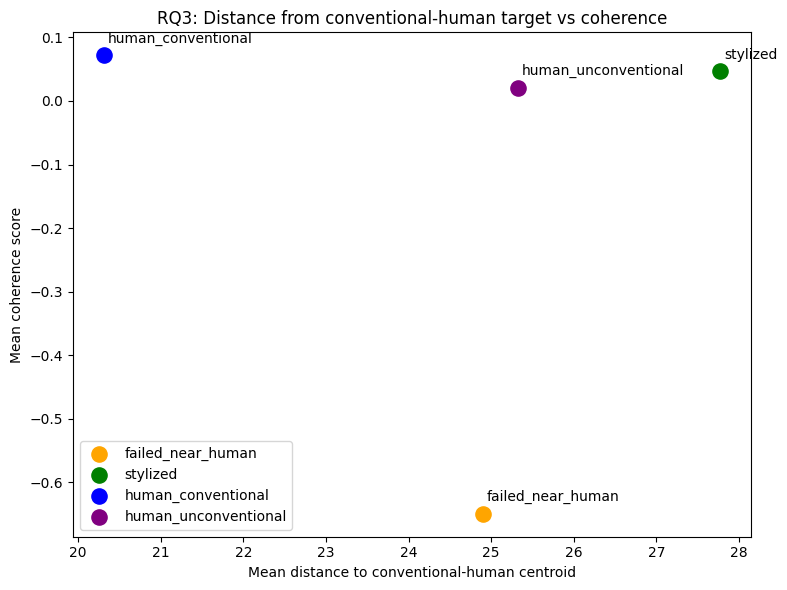

In [42]:
import matplotlib.pyplot as plt

group_points = {
    "failed_near_human": (
        rq3_boot_df["mean_dist_failed_near_human"].mean(),
        rq3_boot_df["mean_coh_failed_near_human"].mean()
    ),
    "stylized": (
        rq3_boot_df["mean_dist_stylized"].mean(),
        rq3_boot_df["mean_coh_stylized"].mean()
    ),
    "human_conventional": (
        rq3_boot_df["mean_dist_human_conventional"].mean(),
        rq3_boot_df["mean_coh_human_conventional"].mean()
    ),
    "human_unconventional": (
        rq3_boot_df["mean_dist_human_unconventional"].mean(),
        rq3_boot_df["mean_coh_human_unconventional"].mean()
    )
}

colors = {
    "failed_near_human": "orange",
    "stylized": "green",
    "human_conventional": "blue",
    "human_unconventional": "purple"
}

plt.figure(figsize=(8, 6))

for group, (dist_mean, coh_mean) in group_points.items():
    plt.scatter(dist_mean, coh_mean, s=120, color=colors[group], label=group)
    plt.text(dist_mean + 0.05, coh_mean + 0.02, group, fontsize=10)

plt.xlabel("Mean distance to conventional-human centroid")
plt.ylabel("Mean coherence score")
plt.title("RQ3: Distance from conventional-human target vs coherence")
plt.legend()
plt.tight_layout()
plt.savefig("rq3_distance_vs_coherence.png", dpi=200)
plt.show()

In [43]:
rq3_boot_df.to_csv("rq3_bootstrap_summary.csv", index=False)
rq3_all_df.to_csv("rq3_bootstrap_all_rows.csv", index=False)

print("Saved:")
print("- rq3_bootstrap_summary.csv")
print("- rq3_bootstrap_all_rows.csv")
print("- rq3_distance_vs_coherence.png")

Saved:
- rq3_bootstrap_summary.csv
- rq3_bootstrap_all_rows.csv
- rq3_distance_vs_coherence.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# REPORT OUTPUTS: TABLES + FIGURES FOR RQ1, RQ2, RQ3
# Safe version: creates missing difference columns first
# Assumes these already exist:
# rq1_boot_df, rq1_knn_boot_df, rq2_boot_df, rq3_boot_df
# =========================================================

OUTDIR = Path("report_outputs")
OUTDIR.mkdir(exist_ok=True)

# -----------------------------
# 0. CREATE MISSING DIFFERENCE COLUMNS IF NEEDED
# -----------------------------
# RQ2
if "diff_failed_minus_stylized" not in rq2_boot_df.columns:
    rq2_boot_df["diff_failed_minus_stylized"] = (
        rq2_boot_df["mean_failed_near_human"] - rq2_boot_df["mean_stylized"]
    )

if "diff_failed_minus_conventional" not in rq2_boot_df.columns:
    rq2_boot_df["diff_failed_minus_conventional"] = (
        rq2_boot_df["mean_failed_near_human"] - rq2_boot_df["mean_human_conventional"]
    )

if "diff_failed_minus_unconventional" not in rq2_boot_df.columns:
    rq2_boot_df["diff_failed_minus_unconventional"] = (
        rq2_boot_df["mean_failed_near_human"] - rq2_boot_df["mean_human_unconventional"]
    )

# RQ3
if "diff_dist_unconventional_minus_conventional" not in rq3_boot_df.columns:
    rq3_boot_df["diff_dist_unconventional_minus_conventional"] = (
        rq3_boot_df["mean_dist_human_unconventional"] -
        rq3_boot_df["mean_dist_human_conventional"]
    )

if "diff_dist_failed_minus_conventional" not in rq3_boot_df.columns:
    rq3_boot_df["diff_dist_failed_minus_conventional"] = (
        rq3_boot_df["mean_dist_failed_near_human"] -
        rq3_boot_df["mean_dist_human_conventional"]
    )

if "diff_dist_failed_minus_unconventional" not in rq3_boot_df.columns:
    rq3_boot_df["diff_dist_failed_minus_unconventional"] = (
        rq3_boot_df["mean_dist_failed_near_human"] -
        rq3_boot_df["mean_dist_human_unconventional"]
    )

if "diff_coh_unconventional_minus_failed" not in rq3_boot_df.columns:
    rq3_boot_df["diff_coh_unconventional_minus_failed"] = (
        rq3_boot_df["mean_coh_human_unconventional"] -
        rq3_boot_df["mean_coh_failed_near_human"]
    )

if "diff_coh_conventional_minus_failed" not in rq3_boot_df.columns:
    rq3_boot_df["diff_coh_conventional_minus_failed"] = (
        rq3_boot_df["mean_coh_human_conventional"] -
        rq3_boot_df["mean_coh_failed_near_human"]
    )

if "diff_coh_unconventional_minus_conventional" not in rq3_boot_df.columns:
    rq3_boot_df["diff_coh_unconventional_minus_conventional"] = (
        rq3_boot_df["mean_coh_human_unconventional"] -
        rq3_boot_df["mean_coh_human_conventional"]
    )

# -----------------------------
# 1. HELPERS
# -----------------------------
def make_summary_table(df, cols, filename):
    rows = []
    for col in cols:
        rows.append({
            "metric": col,
            "mean": df[col].mean(),
            "ci_2.5": df[col].quantile(0.025),
            "ci_97.5": df[col].quantile(0.975)
        })
    out = pd.DataFrame(rows)
    out.to_csv(OUTDIR / filename, index=False)
    return out

def rounded_table(df, decimals=3):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(decimals)
    return out

# -----------------------------
# 2. TABLES
# -----------------------------
rq1_table = make_summary_table(
    rq1_boot_df,
    cols=[
        "mean_dist_to_conventional",
        "mean_dist_to_unconventional",
        "mean_delta",
        "prop_centroid_unconventional",
        "prop_nn_unconventional"
    ],
    filename="rq1_summary_table.csv"
)

rq1_knn_table = make_summary_table(
    rq1_knn_boot_df,
    cols=["prop_pred_unconventional"],
    filename="rq1_knn_summary_table.csv"
)

rq2_table = make_summary_table(
    rq2_boot_df,
    cols=[
        "mean_failed_near_human",
        "mean_stylized",
        "mean_human_conventional",
        "mean_human_unconventional",
        "diff_failed_minus_stylized",
        "diff_failed_minus_conventional",
        "diff_failed_minus_unconventional"
    ],
    filename="rq2_summary_table.csv"
)

rq3_table = make_summary_table(
    rq3_boot_df,
    cols=[
        "mean_dist_failed_near_human",
        "mean_dist_stylized",
        "mean_dist_human_conventional",
        "mean_dist_human_unconventional",
        "mean_coh_failed_near_human",
        "mean_coh_stylized",
        "mean_coh_human_conventional",
        "mean_coh_human_unconventional",
        "diff_dist_unconventional_minus_conventional",
        "diff_dist_failed_minus_conventional",
        "diff_dist_failed_minus_unconventional",
        "diff_coh_unconventional_minus_failed",
        "diff_coh_conventional_minus_failed",
        "diff_coh_unconventional_minus_conventional"
    ],
    filename="rq3_summary_table.csv"
)

main_results_rows = [
    {
        "RQ": "RQ1",
        "Metric": "Mean distance to conventional humans",
        "Mean": rq1_boot_df["mean_dist_to_conventional"].mean(),
        "CI 2.5%": rq1_boot_df["mean_dist_to_conventional"].quantile(0.025),
        "CI 97.5%": rq1_boot_df["mean_dist_to_conventional"].quantile(0.975)
    },
    {
        "RQ": "RQ1",
        "Metric": "Mean distance to unconventional humans",
        "Mean": rq1_boot_df["mean_dist_to_unconventional"].mean(),
        "CI 2.5%": rq1_boot_df["mean_dist_to_unconventional"].quantile(0.025),
        "CI 97.5%": rq1_boot_df["mean_dist_to_unconventional"].quantile(0.975)
    },
    {
        "RQ": "RQ1",
        "Metric": "Mean delta (conv - unconv)",
        "Mean": rq1_boot_df["mean_delta"].mean(),
        "CI 2.5%": rq1_boot_df["mean_delta"].quantile(0.025),
        "CI 97.5%": rq1_boot_df["mean_delta"].quantile(0.975)
    },
    {
        "RQ": "RQ2",
        "Metric": "Mean coherence: failed near-human",
        "Mean": rq2_boot_df["mean_failed_near_human"].mean(),
        "CI 2.5%": rq2_boot_df["mean_failed_near_human"].quantile(0.025),
        "CI 97.5%": rq2_boot_df["mean_failed_near_human"].quantile(0.975)
    },
    {
        "RQ": "RQ2",
        "Metric": "Mean coherence: human unconventional",
        "Mean": rq2_boot_df["mean_human_unconventional"].mean(),
        "CI 2.5%": rq2_boot_df["mean_human_unconventional"].quantile(0.025),
        "CI 97.5%": rq2_boot_df["mean_human_unconventional"].quantile(0.975)
    },
    {
        "RQ": "RQ3",
        "Metric": "Distance diff: unconventional - conventional",
        "Mean": rq3_boot_df["diff_dist_unconventional_minus_conventional"].mean(),
        "CI 2.5%": rq3_boot_df["diff_dist_unconventional_minus_conventional"].quantile(0.025),
        "CI 97.5%": rq3_boot_df["diff_dist_unconventional_minus_conventional"].quantile(0.975)
    },
    {
        "RQ": "RQ3",
        "Metric": "Coherence diff: unconventional - failed near-human",
        "Mean": rq3_boot_df["diff_coh_unconventional_minus_failed"].mean(),
        "CI 2.5%": rq3_boot_df["diff_coh_unconventional_minus_failed"].quantile(0.025),
        "CI 97.5%": rq3_boot_df["diff_coh_unconventional_minus_failed"].quantile(0.975)
    }
]

main_results_table = pd.DataFrame(main_results_rows)
main_results_table.to_csv(OUTDIR / "main_results_table.csv", index=False)

rounded_rq1 = rounded_table(rq1_table)
rounded_rq1_knn = rounded_table(rq1_knn_table)
rounded_rq2 = rounded_table(rq2_table)
rounded_rq3 = rounded_table(rq3_table)
rounded_main = rounded_table(main_results_table)

rounded_rq1.to_csv(OUTDIR / "rq1_summary_table_rounded.csv", index=False)
rounded_rq1_knn.to_csv(OUTDIR / "rq1_knn_summary_table_rounded.csv", index=False)
rounded_rq2.to_csv(OUTDIR / "rq2_summary_table_rounded.csv", index=False)
rounded_rq3.to_csv(OUTDIR / "rq3_summary_table_rounded.csv", index=False)
rounded_main.to_csv(OUTDIR / "main_results_table_rounded.csv", index=False)

# -----------------------------
# 3. FIGURES
# -----------------------------

# RQ1 distance bar
rq1_bar_labels = ["To conventional", "To unconventional"]
rq1_bar_means = [
    rq1_boot_df["mean_dist_to_conventional"].mean(),
    rq1_boot_df["mean_dist_to_unconventional"].mean()
]
rq1_bar_err_low = [
    rq1_boot_df["mean_dist_to_conventional"].mean() - rq1_boot_df["mean_dist_to_conventional"].quantile(0.025),
    rq1_boot_df["mean_dist_to_unconventional"].mean() - rq1_boot_df["mean_dist_to_unconventional"].quantile(0.025),
]
rq1_bar_err_high = [
    rq1_boot_df["mean_dist_to_conventional"].quantile(0.975) - rq1_boot_df["mean_dist_to_conventional"].mean(),
    rq1_boot_df["mean_dist_to_unconventional"].quantile(0.975) - rq1_boot_df["mean_dist_to_unconventional"].mean(),
]

plt.figure(figsize=(7,5))
plt.bar(rq1_bar_labels, rq1_bar_means)
plt.errorbar(rq1_bar_labels, rq1_bar_means, yerr=[rq1_bar_err_low, rq1_bar_err_high], fmt='none', capsize=5)
plt.ylabel("Mean distance")
plt.title("RQ1: Failed near-human distance to human reference groups")
plt.tight_layout()
plt.savefig(OUTDIR / "rq1_distance_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ1 delta histogram
plt.figure(figsize=(7,5))
plt.hist(rq1_boot_df["mean_delta"], bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Mean delta (distance to conventional - distance to unconventional)")
plt.ylabel("Frequency")
plt.title("RQ1: Bootstrap distribution of mean delta")
plt.tight_layout()
plt.savefig(OUTDIR / "rq1_delta_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ1 k-NN histogram
plt.figure(figsize=(7,5))
plt.hist(rq1_knn_boot_df["prop_pred_unconventional"], bins=8)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Proportion predicted as unconventional")
plt.ylabel("Frequency")
plt.title("RQ1: k-NN bootstrap distribution")
plt.tight_layout()
plt.savefig(OUTDIR / "rq1_knn_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ2 coherence bar
rq2_groups = [
    "failed_near_human",
    "stylized",
    "human_conventional",
    "human_unconventional"
]
rq2_mean_map = {
    "failed_near_human": rq2_boot_df["mean_failed_near_human"],
    "stylized": rq2_boot_df["mean_stylized"],
    "human_conventional": rq2_boot_df["mean_human_conventional"],
    "human_unconventional": rq2_boot_df["mean_human_unconventional"]
}

means = [rq2_mean_map[g].mean() for g in rq2_groups]
err_low = [rq2_mean_map[g].mean() - rq2_mean_map[g].quantile(0.025) for g in rq2_groups]
err_high = [rq2_mean_map[g].quantile(0.975) - rq2_mean_map[g].mean() for g in rq2_groups]

plt.figure(figsize=(8,5))
plt.bar(rq2_groups, means)
plt.errorbar(rq2_groups, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.ylabel("Mean coherence score")
plt.title("RQ2: Coherence across groups")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTDIR / "rq2_coherence_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ2 pairwise differences
rq2_diff_cols = {
    "Failed - Stylized": "diff_failed_minus_stylized",
    "Failed - Conventional": "diff_failed_minus_conventional",
    "Failed - Unconventional": "diff_failed_minus_unconventional"
}
labels = list(rq2_diff_cols.keys())
means = [rq2_boot_df[col].mean() for col in rq2_diff_cols.values()]
err_low = [rq2_boot_df[col].mean() - rq2_boot_df[col].quantile(0.025) for col in rq2_diff_cols.values()]
err_high = [rq2_boot_df[col].quantile(0.975) - rq2_boot_df[col].mean() for col in rq2_diff_cols.values()]

plt.figure(figsize=(8,5))
plt.bar(labels, means)
plt.errorbar(labels, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.axhline(0, linestyle="--")
plt.ylabel("Difference in coherence score")
plt.title("RQ2: Pairwise coherence differences")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTDIR / "rq2_pairwise_differences_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ3 distance by group
rq3_groups = [
    "failed_near_human",
    "stylized",
    "human_conventional",
    "human_unconventional"
]
rq3_dist_map = {
    "failed_near_human": rq3_boot_df["mean_dist_failed_near_human"],
    "stylized": rq3_boot_df["mean_dist_stylized"],
    "human_conventional": rq3_boot_df["mean_dist_human_conventional"],
    "human_unconventional": rq3_boot_df["mean_dist_human_unconventional"]
}

means = [rq3_dist_map[g].mean() for g in rq3_groups]
err_low = [rq3_dist_map[g].mean() - rq3_dist_map[g].quantile(0.025) for g in rq3_groups]
err_high = [rq3_dist_map[g].quantile(0.975) - rq3_dist_map[g].mean() for g in rq3_groups]

plt.figure(figsize=(8,5))
plt.bar(rq3_groups, means)
plt.errorbar(rq3_groups, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.ylabel("Mean distance to conventional-human centroid")
plt.title("RQ3: Distance to conventional-human centroid")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTDIR / "rq3_distance_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ3 coherence by group
rq3_coh_map = {
    "failed_near_human": rq3_boot_df["mean_coh_failed_near_human"],
    "stylized": rq3_boot_df["mean_coh_stylized"],
    "human_conventional": rq3_boot_df["mean_coh_human_conventional"],
    "human_unconventional": rq3_boot_df["mean_coh_human_unconventional"]
}

means = [rq3_coh_map[g].mean() for g in rq3_groups]
err_low = [rq3_coh_map[g].mean() - rq3_coh_map[g].quantile(0.025) for g in rq3_groups]
err_high = [rq3_coh_map[g].quantile(0.975) - rq3_coh_map[g].mean() for g in rq3_groups]

plt.figure(figsize=(8,5))
plt.bar(rq3_groups, means)
plt.errorbar(rq3_groups, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.ylabel("Mean coherence score")
plt.title("RQ3: Coherence across groups")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTDIR / "rq3_coherence_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ3 key contrasts
rq3_contrast_cols = {
    "Unconv - Conv distance": "diff_dist_unconventional_minus_conventional",
    "Failed - Conv distance": "diff_dist_failed_minus_conventional",
    "Failed - Unconv distance": "diff_dist_failed_minus_unconventional",
    "Unconv - Failed coherence": "diff_coh_unconventional_minus_failed",
    "Conv - Failed coherence": "diff_coh_conventional_minus_failed",
    "Unconv - Conv coherence": "diff_coh_unconventional_minus_conventional"
}

labels = list(rq3_contrast_cols.keys())
means = [rq3_boot_df[col].mean() for col in rq3_contrast_cols.values()]
err_low = [rq3_boot_df[col].mean() - rq3_boot_df[col].quantile(0.025) for col in rq3_contrast_cols.values()]
err_high = [rq3_boot_df[col].quantile(0.975) - rq3_boot_df[col].mean() for col in rq3_contrast_cols.values()]

plt.figure(figsize=(10,6))
plt.bar(labels, means)
plt.errorbar(labels, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.axhline(0, linestyle="--")
plt.ylabel("Difference")
plt.title("RQ3: Key pairwise contrasts")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTDIR / "rq3_key_contrasts_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ3 distance vs coherence scatter
group_points = {
    "failed_near_human": (
        rq3_boot_df["mean_dist_failed_near_human"].mean(),
        rq3_boot_df["mean_coh_failed_near_human"].mean()
    ),
    "stylized": (
        rq3_boot_df["mean_dist_stylized"].mean(),
        rq3_boot_df["mean_coh_stylized"].mean()
    ),
    "human_conventional": (
        rq3_boot_df["mean_dist_human_conventional"].mean(),
        rq3_boot_df["mean_coh_human_conventional"].mean()
    ),
    "human_unconventional": (
        rq3_boot_df["mean_dist_human_unconventional"].mean(),
        rq3_boot_df["mean_coh_human_unconventional"].mean()
    )
}

plt.figure(figsize=(8,6))
for group, (x, y) in group_points.items():
    plt.scatter(x, y, s=120)
    plt.text(x + 0.08, y + 0.02, group, fontsize=10)

plt.xlabel("Mean distance to conventional-human centroid")
plt.ylabel("Mean coherence score")
plt.title("RQ3: Distance from conventional norm vs coherence")
plt.tight_layout()
plt.savefig(OUTDIR / "rq3_distance_vs_coherence_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved files:")
for p in sorted(OUTDIR.iterdir()):
    print("-", p.name)

print("\nMain results table:")
display(rounded_main)

KeyError: 'diff_failed_minus_stylized'

In [54]:
df_ok.to_csv("rq1_valid_images_metadata.csv", index=False)
np.save("rq1_all_embeddings.npy", X)
rq1_boot_df.to_csv("rq1_bootstrap_summary.csv", index=False)
rq1_all_df.to_csv("rq1_bootstrap_all_image_results.csv", index=False)

print("Saved:")
print("- rq1_valid_images_metadata.csv")
print("- rq1_all_embeddings.npy")
print("- rq1_bootstrap_summary.csv")
print("- rq1_bootstrap_all_image_results.csv")

Saved:
- rq1_valid_images_metadata.csv
- rq1_all_embeddings.npy
- rq1_bootstrap_summary.csv
- rq1_bootstrap_all_image_results.csv


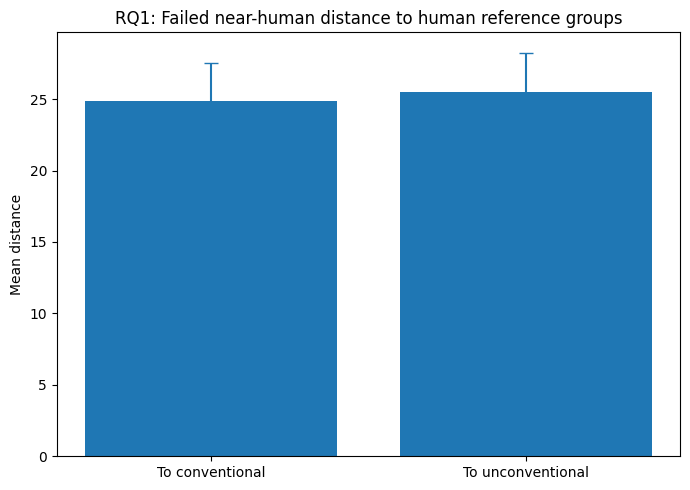

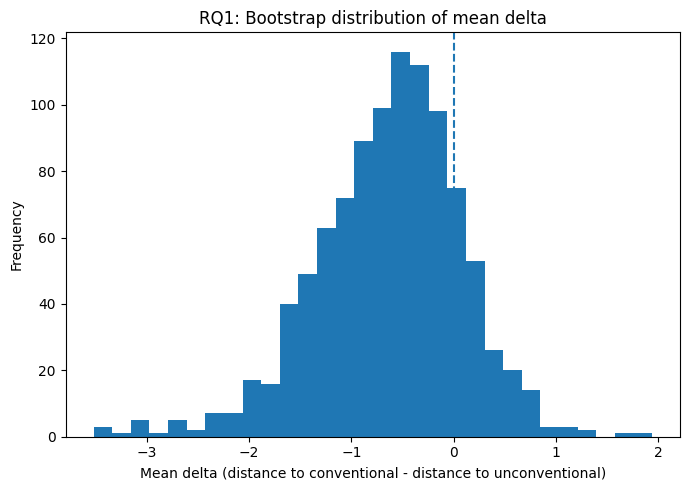

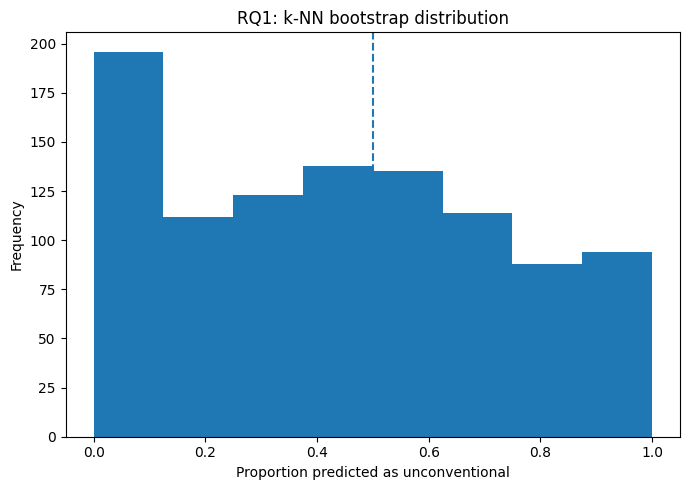

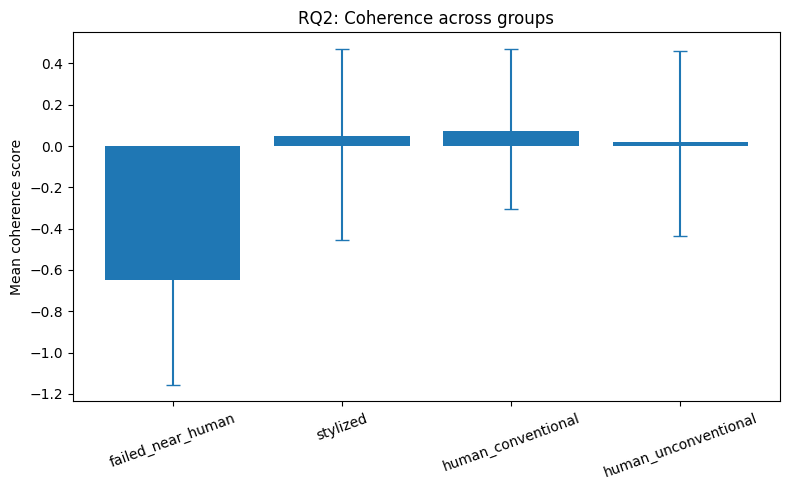

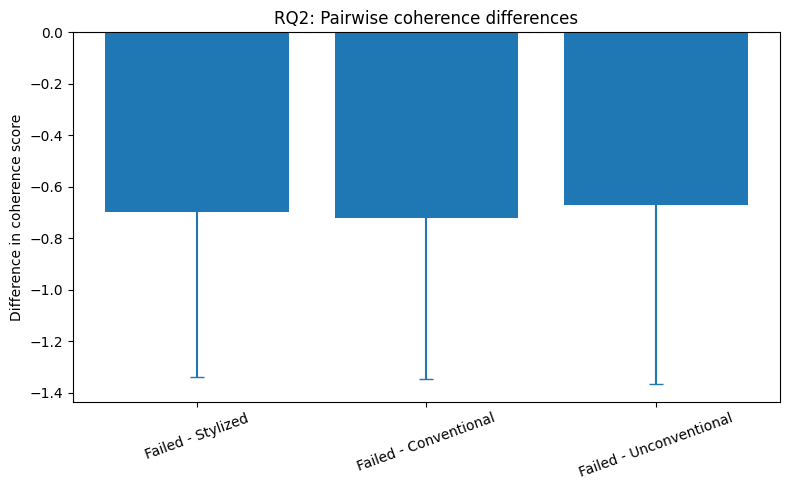

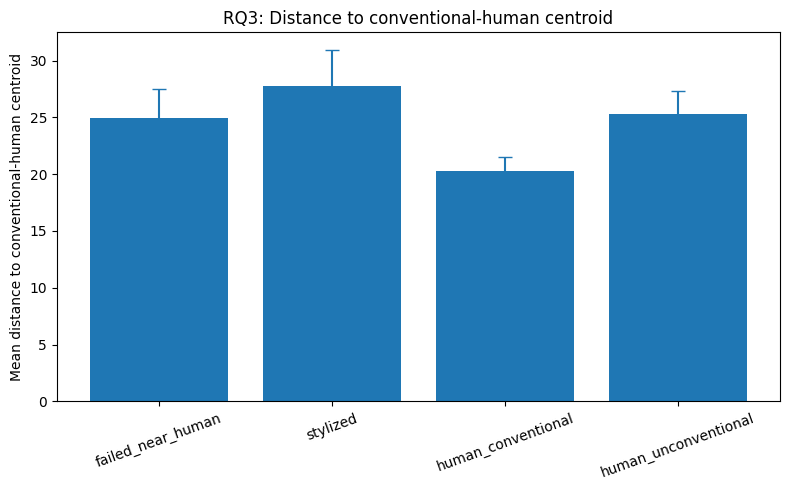

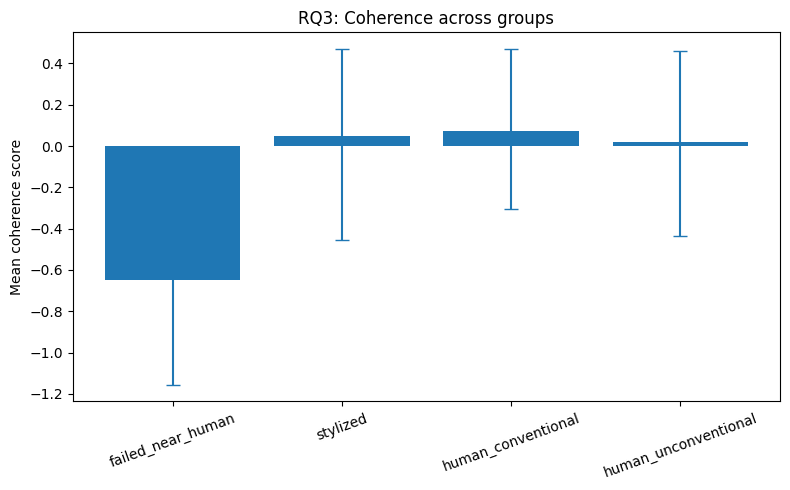

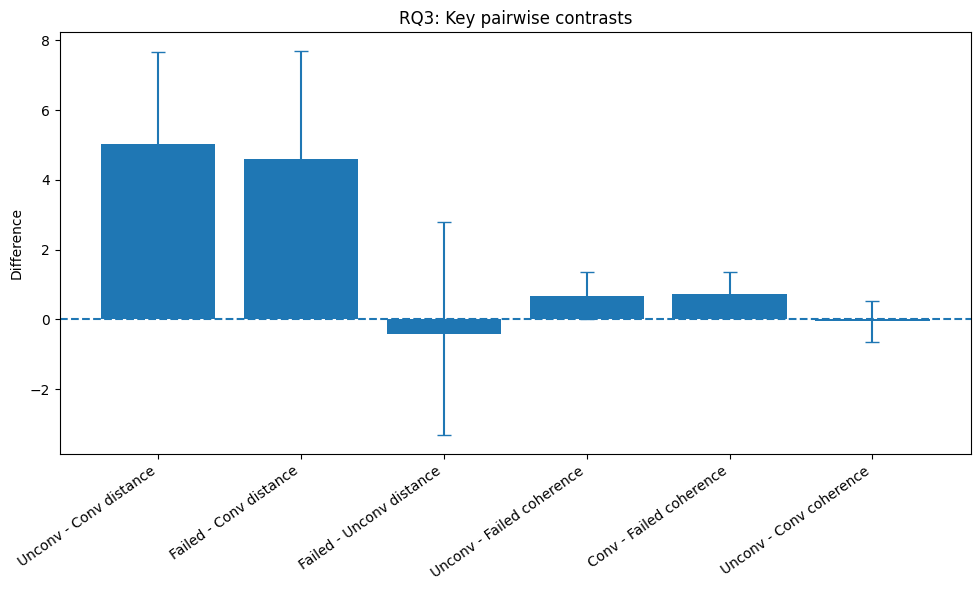

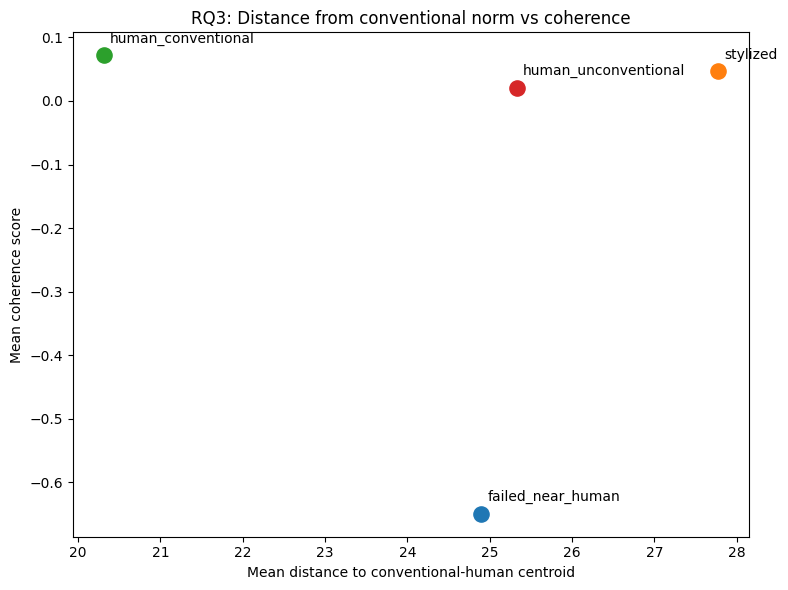


Saved files:
- main_results_table.csv
- main_results_table_rounded.csv
- rq1_delta_histogram.png
- rq1_distance_bar.png
- rq1_knn_histogram.png
- rq1_knn_summary_table.csv
- rq1_knn_summary_table_rounded.csv
- rq1_summary_table.csv
- rq1_summary_table_rounded.csv
- rq2_coherence_bar.png
- rq2_pairwise_differences_bar.png
- rq2_summary_table.csv
- rq2_summary_table_rounded.csv
- rq3_coherence_bar.png
- rq3_distance_bar.png
- rq3_distance_vs_coherence_scatter.png
- rq3_key_contrasts_bar.png
- rq3_summary_table.csv
- rq3_summary_table_rounded.csv

Main results table:


,RQ,Metric,Mean,CI 2.5%,CI 97.5%
0,RQ1,Mean distance to conventional humans,24.898,23.173,27.529
1,RQ1,Mean distance to unconventional humans,25.535,23.692,28.264
2,RQ1,Mean delta (conv - unconv),-0.637,-2.222,0.653
3,RQ2,Mean coherence: failed near-human,-0.650,-1.156,-0.229
4,RQ2,Mean coherence: human unconventional,0.021,-0.433,0.460
5,RQ3,Distance diff: unconventional - conventional,5.017,2.786,7.676
6,RQ3,Coherence diff: unconventional - failed near-h...,0.671,0.004,1.366


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# REPORT OUTPUTS: TABLES + FIGURES FOR RQ1, RQ2, RQ3
# Safe version: creates missing difference columns first
# Assumes these already exist:
# rq1_boot_df, rq1_knn_boot_df, rq2_boot_df, rq3_boot_df
# =========================================================

OUTDIR = Path("report_outputs")
OUTDIR.mkdir(exist_ok=True)

# -----------------------------
# 0. CREATE MISSING DIFFERENCE COLUMNS IF NEEDED
# -----------------------------
# RQ2
if "diff_failed_minus_stylized" not in rq2_boot_df.columns:
    rq2_boot_df["diff_failed_minus_stylized"] = (
        rq2_boot_df["mean_failed_near_human"] - rq2_boot_df["mean_stylized"]
    )

if "diff_failed_minus_conventional" not in rq2_boot_df.columns:
    rq2_boot_df["diff_failed_minus_conventional"] = (
        rq2_boot_df["mean_failed_near_human"] - rq2_boot_df["mean_human_conventional"]
    )

if "diff_failed_minus_unconventional" not in rq2_boot_df.columns:
    rq2_boot_df["diff_failed_minus_unconventional"] = (
        rq2_boot_df["mean_failed_near_human"] - rq2_boot_df["mean_human_unconventional"]
    )

# RQ3
if "diff_dist_unconventional_minus_conventional" not in rq3_boot_df.columns:
    rq3_boot_df["diff_dist_unconventional_minus_conventional"] = (
        rq3_boot_df["mean_dist_human_unconventional"] -
        rq3_boot_df["mean_dist_human_conventional"]
    )

if "diff_dist_failed_minus_conventional" not in rq3_boot_df.columns:
    rq3_boot_df["diff_dist_failed_minus_conventional"] = (
        rq3_boot_df["mean_dist_failed_near_human"] -
        rq3_boot_df["mean_dist_human_conventional"]
    )

if "diff_dist_failed_minus_unconventional" not in rq3_boot_df.columns:
    rq3_boot_df["diff_dist_failed_minus_unconventional"] = (
        rq3_boot_df["mean_dist_failed_near_human"] -
        rq3_boot_df["mean_dist_human_unconventional"]
    )

if "diff_coh_unconventional_minus_failed" not in rq3_boot_df.columns:
    rq3_boot_df["diff_coh_unconventional_minus_failed"] = (
        rq3_boot_df["mean_coh_human_unconventional"] -
        rq3_boot_df["mean_coh_failed_near_human"]
    )

if "diff_coh_conventional_minus_failed" not in rq3_boot_df.columns:
    rq3_boot_df["diff_coh_conventional_minus_failed"] = (
        rq3_boot_df["mean_coh_human_conventional"] -
        rq3_boot_df["mean_coh_failed_near_human"]
    )

if "diff_coh_unconventional_minus_conventional" not in rq3_boot_df.columns:
    rq3_boot_df["diff_coh_unconventional_minus_conventional"] = (
        rq3_boot_df["mean_coh_human_unconventional"] -
        rq3_boot_df["mean_coh_human_conventional"]
    )

# -----------------------------
# 1. HELPERS
# -----------------------------
def make_summary_table(df, cols, filename):
    rows = []
    for col in cols:
        rows.append({
            "metric": col,
            "mean": df[col].mean(),
            "ci_2.5": df[col].quantile(0.025),
            "ci_97.5": df[col].quantile(0.975)
        })
    out = pd.DataFrame(rows)
    out.to_csv(OUTDIR / filename, index=False)
    return out

def rounded_table(df, decimals=3):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(decimals)
    return out

# -----------------------------
# 2. TABLES
# -----------------------------
rq1_table = make_summary_table(
    rq1_boot_df,
    cols=[
        "mean_dist_to_conventional",
        "mean_dist_to_unconventional",
        "mean_delta",
        "prop_centroid_unconventional",
        "prop_nn_unconventional"
    ],
    filename="rq1_summary_table.csv"
)

rq1_knn_table = make_summary_table(
    rq1_knn_boot_df,
    cols=["prop_pred_unconventional"],
    filename="rq1_knn_summary_table.csv"
)

rq2_table = make_summary_table(
    rq2_boot_df,
    cols=[
        "mean_failed_near_human",
        "mean_stylized",
        "mean_human_conventional",
        "mean_human_unconventional",
        "diff_failed_minus_stylized",
        "diff_failed_minus_conventional",
        "diff_failed_minus_unconventional"
    ],
    filename="rq2_summary_table.csv"
)

rq3_table = make_summary_table(
    rq3_boot_df,
    cols=[
        "mean_dist_failed_near_human",
        "mean_dist_stylized",
        "mean_dist_human_conventional",
        "mean_dist_human_unconventional",
        "mean_coh_failed_near_human",
        "mean_coh_stylized",
        "mean_coh_human_conventional",
        "mean_coh_human_unconventional",
        "diff_dist_unconventional_minus_conventional",
        "diff_dist_failed_minus_conventional",
        "diff_dist_failed_minus_unconventional",
        "diff_coh_unconventional_minus_failed",
        "diff_coh_conventional_minus_failed",
        "diff_coh_unconventional_minus_conventional"
    ],
    filename="rq3_summary_table.csv"
)

main_results_rows = [
    {
        "RQ": "RQ1",
        "Metric": "Mean distance to conventional humans",
        "Mean": rq1_boot_df["mean_dist_to_conventional"].mean(),
        "CI 2.5%": rq1_boot_df["mean_dist_to_conventional"].quantile(0.025),
        "CI 97.5%": rq1_boot_df["mean_dist_to_conventional"].quantile(0.975)
    },
    {
        "RQ": "RQ1",
        "Metric": "Mean distance to unconventional humans",
        "Mean": rq1_boot_df["mean_dist_to_unconventional"].mean(),
        "CI 2.5%": rq1_boot_df["mean_dist_to_unconventional"].quantile(0.025),
        "CI 97.5%": rq1_boot_df["mean_dist_to_unconventional"].quantile(0.975)
    },
    {
        "RQ": "RQ1",
        "Metric": "Mean delta (conv - unconv)",
        "Mean": rq1_boot_df["mean_delta"].mean(),
        "CI 2.5%": rq1_boot_df["mean_delta"].quantile(0.025),
        "CI 97.5%": rq1_boot_df["mean_delta"].quantile(0.975)
    },
    {
        "RQ": "RQ2",
        "Metric": "Mean coherence: failed near-human",
        "Mean": rq2_boot_df["mean_failed_near_human"].mean(),
        "CI 2.5%": rq2_boot_df["mean_failed_near_human"].quantile(0.025),
        "CI 97.5%": rq2_boot_df["mean_failed_near_human"].quantile(0.975)
    },
    {
        "RQ": "RQ2",
        "Metric": "Mean coherence: human unconventional",
        "Mean": rq2_boot_df["mean_human_unconventional"].mean(),
        "CI 2.5%": rq2_boot_df["mean_human_unconventional"].quantile(0.025),
        "CI 97.5%": rq2_boot_df["mean_human_unconventional"].quantile(0.975)
    },
    {
        "RQ": "RQ3",
        "Metric": "Distance diff: unconventional - conventional",
        "Mean": rq3_boot_df["diff_dist_unconventional_minus_conventional"].mean(),
        "CI 2.5%": rq3_boot_df["diff_dist_unconventional_minus_conventional"].quantile(0.025),
        "CI 97.5%": rq3_boot_df["diff_dist_unconventional_minus_conventional"].quantile(0.975)
    },
    {
        "RQ": "RQ3",
        "Metric": "Coherence diff: unconventional - failed near-human",
        "Mean": rq3_boot_df["diff_coh_unconventional_minus_failed"].mean(),
        "CI 2.5%": rq3_boot_df["diff_coh_unconventional_minus_failed"].quantile(0.025),
        "CI 97.5%": rq3_boot_df["diff_coh_unconventional_minus_failed"].quantile(0.975)
    }
]

main_results_table = pd.DataFrame(main_results_rows)
main_results_table.to_csv(OUTDIR / "main_results_table.csv", index=False)

rounded_rq1 = rounded_table(rq1_table)
rounded_rq1_knn = rounded_table(rq1_knn_table)
rounded_rq2 = rounded_table(rq2_table)
rounded_rq3 = rounded_table(rq3_table)
rounded_main = rounded_table(main_results_table)

rounded_rq1.to_csv(OUTDIR / "rq1_summary_table_rounded.csv", index=False)
rounded_rq1_knn.to_csv(OUTDIR / "rq1_knn_summary_table_rounded.csv", index=False)
rounded_rq2.to_csv(OUTDIR / "rq2_summary_table_rounded.csv", index=False)
rounded_rq3.to_csv(OUTDIR / "rq3_summary_table_rounded.csv", index=False)
rounded_main.to_csv(OUTDIR / "main_results_table_rounded.csv", index=False)

# -----------------------------
# 3. FIGURES
# -----------------------------

# RQ1 distance bar
rq1_bar_labels = ["To conventional", "To unconventional"]
rq1_bar_means = [
    rq1_boot_df["mean_dist_to_conventional"].mean(),
    rq1_boot_df["mean_dist_to_unconventional"].mean()
]
rq1_bar_err_low = [
    rq1_boot_df["mean_dist_to_conventional"].mean() - rq1_boot_df["mean_dist_to_conventional"].quantile(0.025),
    rq1_boot_df["mean_dist_to_unconventional"].mean() - rq1_boot_df["mean_dist_to_unconventional"].quantile(0.025),
]
rq1_bar_err_high = [
    rq1_boot_df["mean_dist_to_conventional"].quantile(0.975) - rq1_boot_df["mean_dist_to_conventional"].mean(),
    rq1_boot_df["mean_dist_to_unconventional"].quantile(0.975) - rq1_boot_df["mean_dist_to_unconventional"].mean(),
]

plt.figure(figsize=(7,5))
plt.bar(rq1_bar_labels, rq1_bar_means)
plt.errorbar(rq1_bar_labels, rq1_bar_means, yerr=[rq1_bar_err_low, rq1_bar_err_high], fmt='none', capsize=5)
plt.ylabel("Mean distance")
plt.title("RQ1: Failed near-human distance to human reference groups")
plt.tight_layout()
plt.savefig(OUTDIR / "rq1_distance_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ1 delta histogram
plt.figure(figsize=(7,5))
plt.hist(rq1_boot_df["mean_delta"], bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Mean delta (distance to conventional - distance to unconventional)")
plt.ylabel("Frequency")
plt.title("RQ1: Bootstrap distribution of mean delta")
plt.tight_layout()
plt.savefig(OUTDIR / "rq1_delta_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ1 k-NN histogram
plt.figure(figsize=(7,5))
plt.hist(rq1_knn_boot_df["prop_pred_unconventional"], bins=8)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Proportion predicted as unconventional")
plt.ylabel("Frequency")
plt.title("RQ1: k-NN bootstrap distribution")
plt.tight_layout()
plt.savefig(OUTDIR / "rq1_knn_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ2 coherence bar
rq2_groups = [
    "failed_near_human",
    "stylized",
    "human_conventional",
    "human_unconventional"
]
rq2_mean_map = {
    "failed_near_human": rq2_boot_df["mean_failed_near_human"],
    "stylized": rq2_boot_df["mean_stylized"],
    "human_conventional": rq2_boot_df["mean_human_conventional"],
    "human_unconventional": rq2_boot_df["mean_human_unconventional"]
}

means = [rq2_mean_map[g].mean() for g in rq2_groups]
err_low = [rq2_mean_map[g].mean() - rq2_mean_map[g].quantile(0.025) for g in rq2_groups]
err_high = [rq2_mean_map[g].quantile(0.975) - rq2_mean_map[g].mean() for g in rq2_groups]

plt.figure(figsize=(8,5))
plt.bar(rq2_groups, means)
plt.errorbar(rq2_groups, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.ylabel("Mean coherence score")
plt.title("RQ2: Coherence across groups")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTDIR / "rq2_coherence_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ2 pairwise differences
rq2_diff_cols = {
    "Failed - Stylized": "diff_failed_minus_stylized",
    "Failed - Conventional": "diff_failed_minus_conventional",
    "Failed - Unconventional": "diff_failed_minus_unconventional"
}
labels = list(rq2_diff_cols.keys())
means = [rq2_boot_df[col].mean() for col in rq2_diff_cols.values()]
err_low = [rq2_boot_df[col].mean() - rq2_boot_df[col].quantile(0.025) for col in rq2_diff_cols.values()]
err_high = [rq2_boot_df[col].quantile(0.975) - rq2_boot_df[col].mean() for col in rq2_diff_cols.values()]

plt.figure(figsize=(8,5))
plt.bar(labels, means)
plt.errorbar(labels, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.axhline(0, linestyle="--")
plt.ylabel("Difference in coherence score")
plt.title("RQ2: Pairwise coherence differences")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTDIR / "rq2_pairwise_differences_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ3 distance by group
rq3_groups = [
    "failed_near_human",
    "stylized",
    "human_conventional",
    "human_unconventional"
]
rq3_dist_map = {
    "failed_near_human": rq3_boot_df["mean_dist_failed_near_human"],
    "stylized": rq3_boot_df["mean_dist_stylized"],
    "human_conventional": rq3_boot_df["mean_dist_human_conventional"],
    "human_unconventional": rq3_boot_df["mean_dist_human_unconventional"]
}

means = [rq3_dist_map[g].mean() for g in rq3_groups]
err_low = [rq3_dist_map[g].mean() - rq3_dist_map[g].quantile(0.025) for g in rq3_groups]
err_high = [rq3_dist_map[g].quantile(0.975) - rq3_dist_map[g].mean() for g in rq3_groups]

plt.figure(figsize=(8,5))
plt.bar(rq3_groups, means)
plt.errorbar(rq3_groups, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.ylabel("Mean distance to conventional-human centroid")
plt.title("RQ3: Distance to conventional-human centroid")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTDIR / "rq3_distance_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ3 coherence by group
rq3_coh_map = {
    "failed_near_human": rq3_boot_df["mean_coh_failed_near_human"],
    "stylized": rq3_boot_df["mean_coh_stylized"],
    "human_conventional": rq3_boot_df["mean_coh_human_conventional"],
    "human_unconventional": rq3_boot_df["mean_coh_human_unconventional"]
}

means = [rq3_coh_map[g].mean() for g in rq3_groups]
err_low = [rq3_coh_map[g].mean() - rq3_coh_map[g].quantile(0.025) for g in rq3_groups]
err_high = [rq3_coh_map[g].quantile(0.975) - rq3_coh_map[g].mean() for g in rq3_groups]

plt.figure(figsize=(8,5))
plt.bar(rq3_groups, means)
plt.errorbar(rq3_groups, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.ylabel("Mean coherence score")
plt.title("RQ3: Coherence across groups")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTDIR / "rq3_coherence_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ3 key contrasts
rq3_contrast_cols = {
    "Unconv - Conv distance": "diff_dist_unconventional_minus_conventional",
    "Failed - Conv distance": "diff_dist_failed_minus_conventional",
    "Failed - Unconv distance": "diff_dist_failed_minus_unconventional",
    "Unconv - Failed coherence": "diff_coh_unconventional_minus_failed",
    "Conv - Failed coherence": "diff_coh_conventional_minus_failed",
    "Unconv - Conv coherence": "diff_coh_unconventional_minus_conventional"
}

labels = list(rq3_contrast_cols.keys())
means = [rq3_boot_df[col].mean() for col in rq3_contrast_cols.values()]
err_low = [rq3_boot_df[col].mean() - rq3_boot_df[col].quantile(0.025) for col in rq3_contrast_cols.values()]
err_high = [rq3_boot_df[col].quantile(0.975) - rq3_boot_df[col].mean() for col in rq3_contrast_cols.values()]

plt.figure(figsize=(10,6))
plt.bar(labels, means)
plt.errorbar(labels, means, yerr=[err_low, err_high], fmt='none', capsize=5)
plt.axhline(0, linestyle="--")
plt.ylabel("Difference")
plt.title("RQ3: Key pairwise contrasts")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTDIR / "rq3_key_contrasts_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ3 distance vs coherence scatter
group_points = {
    "failed_near_human": (
        rq3_boot_df["mean_dist_failed_near_human"].mean(),
        rq3_boot_df["mean_coh_failed_near_human"].mean()
    ),
    "stylized": (
        rq3_boot_df["mean_dist_stylized"].mean(),
        rq3_boot_df["mean_coh_stylized"].mean()
    ),
    "human_conventional": (
        rq3_boot_df["mean_dist_human_conventional"].mean(),
        rq3_boot_df["mean_coh_human_conventional"].mean()
    ),
    "human_unconventional": (
        rq3_boot_df["mean_dist_human_unconventional"].mean(),
        rq3_boot_df["mean_coh_human_unconventional"].mean()
    )
}

plt.figure(figsize=(8,6))
for group, (x, y) in group_points.items():
    plt.scatter(x, y, s=120)
    plt.text(x + 0.08, y + 0.02, group, fontsize=10)

plt.xlabel("Mean distance to conventional-human centroid")
plt.ylabel("Mean coherence score")
plt.title("RQ3: Distance from conventional norm vs coherence")
plt.tight_layout()
plt.savefig(OUTDIR / "rq3_distance_vs_coherence_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved files:")
for p in sorted(OUTDIR.iterdir()):
    print("-", p.name)

print("\nMain results table:")
display(rounded_main)